In [99]:
from google.colab import files
files.upload()

Saving stable.csv to stable (2).csv


{'stable (2).csv': b'Unnamed: 0,Synthesizable,Material ID,Formula,Crystal System,Space Group Symbol,Space Group Number,Sites,Energy Above Hull,Formation Energy,Predicted Stable,Volume,Density,Band Gap,Is Gap Direct,Is Metal,Magnetic Ordering,Total Magnetization,"Bulk Modulus, Voigt","Bulk Modulus, Reuss","Bulk Modulus, VRH","Shear Modulus, Voigt","Shear Modulus, Reuss","Shear Modulus, VRH",Elastic Anisotropy,Weighted Surface Energy,Surface Anisotropy,Shape Factor,Work Function,Piezoelectric Modulus,Total Dielectric Constant,Ionic Dielectric Constant,Static Dielectric Constant\n0,False,mp-11107,Ac2O3,Trigonal,P-3m1,164,5,0.0,-3.737668289999997,True,91.51122386046316,9.109129867325777,3.522599999999999,False,False,NM,0.0,,,,,,,2.519,,,,,,,,\n1,False,mp-580941,AgI,Hexagonal,P6_3mc,186,8,0.0,-0.467759898333332,True,268.4034289336924,5.809898805745882,1.3759,True,False,NM,0.0,,,,,,,,,,,,0.249487808720186,7.119769473334294,2.120445863334295,4.999323609999998\n2,False,mp-11674,Al2Se3,Monoclin

In [100]:
from google.colab import files
files.upload()

Saving unstable.csv to unstable (2).csv


{'unstable (2).csv': b',Synthesizable,Material ID,Formula,Crystal System,Space Group Symbol,Space Group Number,Sites,Energy Above Hull,Formation Energy,Predicted Stable,Volume,Density,Band Gap,Is Gap Direct,Is Metal,Magnetic Ordering,Total Magnetization,"Bulk Modulus, Voigt","Bulk Modulus, Reuss","Bulk Modulus, VRH","Shear Modulus, Voigt","Shear Modulus, Reuss","Shear Modulus, VRH",Elastic Anisotropy,Weighted Surface Energy,Surface Anisotropy,Shape Factor,Work Function,Piezoelectric Modulus,Total Dielectric Constant,Ionic Dielectric Constant,Static Dielectric Constant\n0,False,mp-654937,Ag(CO)2,Monoclinic,C2/c,15,40,0.41785648891666904,-0.6433775220833331,False,559.3675670318058,3.892154022538718,0.7248000000000001,False,False,NM,0.003090599999999,,,,,,,,,,,,,,,\n1,False,mp-574486,Ag2CN2,Monoclinic,P2_1/c,14,20,0.268039843333333,0.268039843333338,False,298.7648598761076,5.686081048745354,1.0037,True,False,NM,0.0003261,,,,,,,,,,,,,,,\n2,False,mp-29536,Ag5CF4,Tetragonal,P-4,81,40,0.24840

In [124]:
df_stable = pd.read_csv("stable.csv")
df_unstable = pd.read_csv("unstable.csv")

df = pd.concat([df_stable, df_unstable], ignore_index=True)

In [125]:
print(df.columns.tolist())

['Unnamed: 0', 'Synthesizable', 'Material ID', 'Formula', 'Crystal System', 'Space Group Symbol', 'Space Group Number', 'Sites', 'Energy Above Hull', 'Formation Energy', 'Predicted Stable', 'Volume', 'Density', 'Band Gap', 'Is Gap Direct', 'Is Metal', 'Magnetic Ordering', 'Total Magnetization', 'Bulk Modulus, Voigt', 'Bulk Modulus, Reuss', 'Bulk Modulus, VRH', 'Shear Modulus, Voigt', 'Shear Modulus, Reuss', 'Shear Modulus, VRH', 'Elastic Anisotropy', 'Weighted Surface Energy', 'Surface Anisotropy', 'Shape Factor', 'Work Function', 'Piezoelectric Modulus', 'Total Dielectric Constant', 'Ionic Dielectric Constant', 'Static Dielectric Constant']


In [126]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Formula": "formula",
    "Formation Energy": "formation_energy",
    "Energy Above Hull": "e_hull",
    "Density": "density",
    "Volume": "volume",
    "Sites": "nsites"
})

In [127]:
df = df[[
    "formula",
    "formation_energy",
    "e_hull",
    "density",
    "volume",
    "nsites"
]]

In [128]:
df = df.dropna()
df = df.drop_duplicates(subset=["formula"])

print("Dataset size:", len(df))

Dataset size: 2642


In [129]:
print(df["e_hull"].describe())

count    2642.000000
mean        0.064785
std         0.162592
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.956763
Name: e_hull, dtype: float64


In [130]:
df["stability"] = (df["e_hull"] < 0.05).astype(int)

print(df["stability"].value_counts())

stability
1    2204
0     438
Name: count, dtype: int64


In [131]:
X = df[[
    "density",
    "volume",
    "nsites"
]]

y_reg = df["formation_energy"]
y_clf = df["stability"]

In [132]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [133]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

reg = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.5664010746008009
R2: 0.3507393941268381


In [134]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf.fit(Xc_train, yc_train)

yc_pred = clf.predict(Xc_test)

print("Accuracy:", accuracy_score(yc_test, yc_pred))
print(confusion_matrix(yc_test, yc_pred))

Accuracy: 0.8657844990548205
[[ 32  59]
 [ 12 426]]


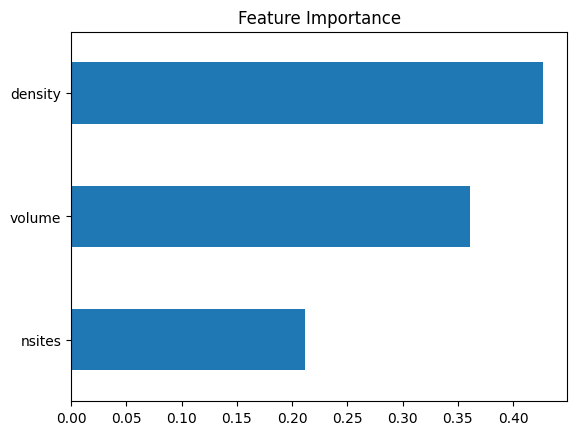

<Figure size 640x480 with 0 Axes>

In [135]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(reg.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")

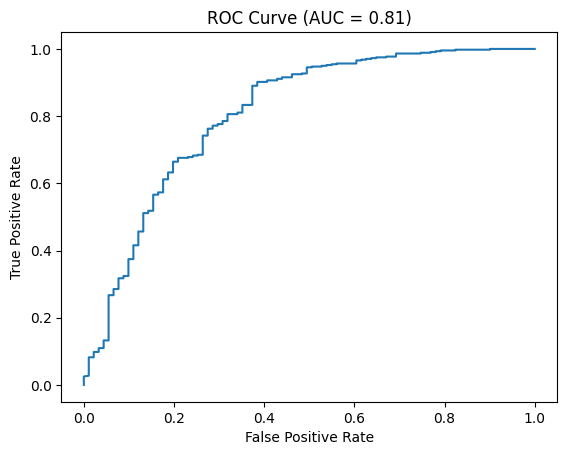

<Figure size 640x480 with 0 Axes>

In [136]:
from sklearn.metrics import roc_curve, auc

y_prob = clf.predict_proba(Xc_test)[:, 1]

fpr, tpr, _ = roc_curve(yc_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")

In [137]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", rmse)
print("R2:", r2_score(y_test, y_pred))

MAE: 0.5664010746008009
RMSE: 0.7346014792691761
R2: 0.3507393941268381


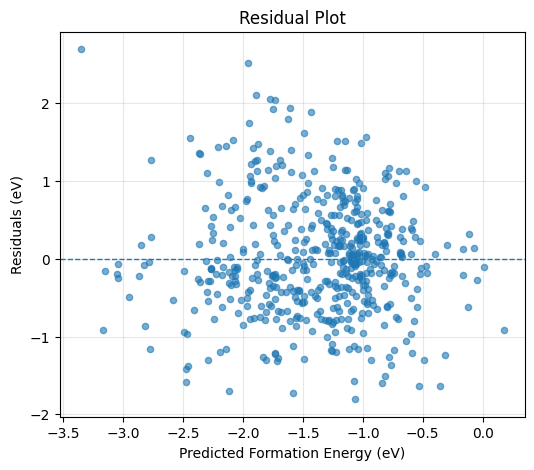

In [138]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals, alpha=0.6, s=20)
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Predicted Formation Energy (eV)")
plt.ylabel("Residuals (eV)")
plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [139]:
df.to_csv("final_dataset.csv", index=False)

In [140]:
from google.colab import files
files.download("final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [141]:
!zip -r results.zip *.png *.csv

updating: final_dataset.csv (deflated 52%)
updating: materials_raw_combined (1).csv (deflated 65%)
updating: materials_raw_combined (2).csv (deflated 65%)
updating: materials_raw_combined (3).csv (deflated 65%)
updating: materials_raw_combined.csv (deflated 65%)
updating: stable (1).csv (deflated 65%)
updating: stable.csv (deflated 65%)
updating: unstable (1).csv (deflated 64%)
updating: unstable.csv (deflated 64%)
updating: confusion_matrix.png (deflated 21%)
updating: feature_importance.png (deflated 98%)
updating: residual_plot.png (deflated 8%)
updating: roc_curve.png (deflated 98%)
updating: stable (2).csv (deflated 65%)
updating: unstable (2).csv (deflated 64%)
updating: materials_clean.csv (deflated 52%)


In [142]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df[["density", "volume", "nsites"]]
y = df["stability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

<Figure size 640x480 with 0 Axes>

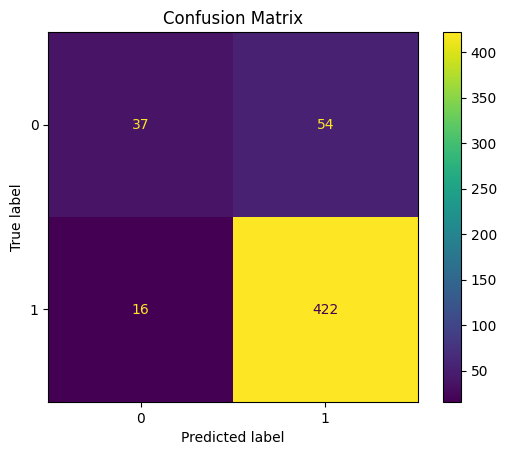

In [143]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure()
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [144]:
# Save dataset
df.to_csv("materials_clean.csv", index=False)

# Save plots
plt.savefig("feature_importance.png", dpi=300)

# Zip everything
!zip -r results.zip *.png *.csv

# Download
from google.colab import files
files.download("results.zip")

updating: final_dataset.csv (deflated 52%)
updating: materials_raw_combined (1).csv (deflated 65%)
updating: materials_raw_combined (2).csv (deflated 65%)
updating: materials_raw_combined (3).csv (deflated 65%)
updating: materials_raw_combined.csv (deflated 65%)
updating: stable (1).csv (deflated 65%)
updating: stable.csv (deflated 65%)
updating: unstable (1).csv (deflated 64%)
updating: unstable.csv (deflated 64%)
updating: confusion_matrix.png (deflated 22%)
updating: feature_importance.png (deflated 98%)
updating: residual_plot.png (deflated 8%)
updating: roc_curve.png (deflated 98%)
updating: stable (2).csv (deflated 65%)
updating: unstable (2).csv (deflated 64%)
updating: materials_clean.csv (deflated 52%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>